In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# KNN for Classification

In [ ]:
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target
print(f'Number of classes:  {len(np.unique(iris_y))}')
print(f'Number of data points: {len(iris_y)}')

Number of classes:  3
Number of data points: 150


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, train_size=.8, random_state=42)
print('Training size: %d' %len(y_train))
print('Test size: %d' %len(y_test))

Training size: 120
Test size: 30


In [ ]:
def visualize_optimal_k(cv_scores, k_values):
  plt.plot(k_values, cv_scores, marker='o')
  plt.xlabel('Number of Neighbors K')
  plt.ylabel('Accuracy')
  plt.xticks(k_values)
  plt.grid()
  plt.show()

def optimal_k(X_train, y_train, k_values):
  cv_scores = []
  for k in k_values:
    knn = neighbors.KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
  visualize_optimal_k(cv_scores, k_values)
  optimal_k = k_values[np.argmax(cv_scores)]
  return optimal_k

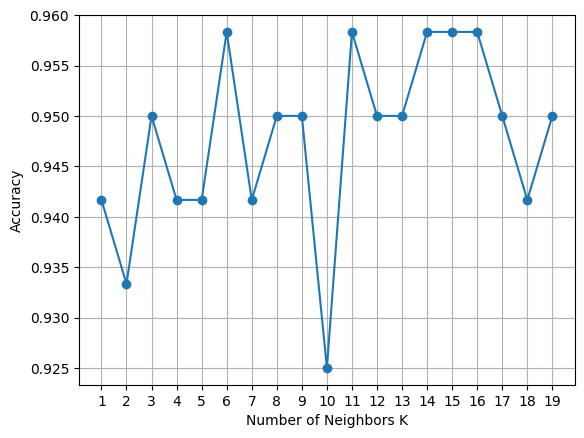

11

In [ ]:
k_values = range(1, 20)
optimal_k(X_train, y_train, k_values)

In [ ]:
clf = neighbors.KNeighborsClassifier(n_neighbors= 8, p=2, weights='distance')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print('Accuracy of the classifier is', accuracy_score(y_test, y_pred) * 100)

Accuracy of the classifier is 100.0


# KNN for regression - Housing prices

In [ ]:
dataset_file_name = '/content/drive/MyDrive/Machine Learning/KNN/Housing.csv'
df = pd.read_csv(dataset_file_name)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.replace({'yes': 1, 'no': 0, 'furnished': 1, 'semi-furnished': 0.5, 'unfurnished': 0}, inplace=True)
missing_values = np.sum(df.isnull().sum())
if(missing_values != 0):
  df.fillna(0, inplace=True)
# df['area'] = df['area'] / df['area'].max()
# df['bedrooms'] = df['bedrooms'] / df['bedrooms'].max()
# df['bathrooms'] = df['bathrooms'] / df['bathrooms'].max()
# df['stories'] = df['stories'] / df['stories'].max()
# df['parking'] = df['parking'] / df['parking'].max()

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, random_state=42)
print('Training size: %d' %len(y_train))
print('Test size: %d' %len(y_test))

Training size: 436
Test size: 109


In [ ]:
def find_optimal_k(X_train, y_train, k_values):
  """
  Finds the optimal k value for KNN regression using cross-validation.

  Args:
    X_train: Training data features.
    y_train: Training data target.
    k_values: A list of k values to evaluate.

  Returns:
    The optimal k value.
  """
  errors = []
  for k in k_values:
    knn = neighbors.KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_train)
    error = mean_squared_error(y_train, y_pred)
    errors.append(error)
  visualize_optimal_k(errors, k_values)
  optimal_k = k_values[np.argmin(errors)]
  return optimal_k

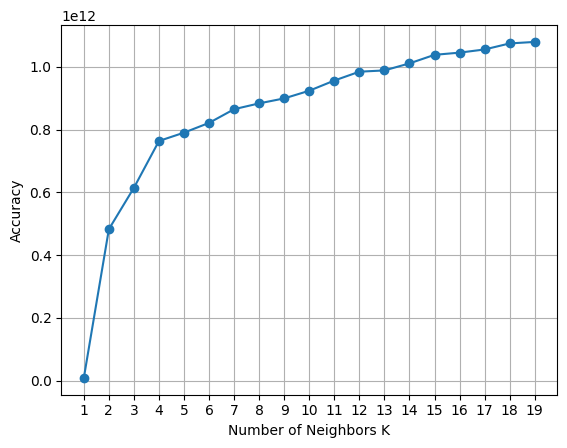

In [ ]:
k_values = range(1, 20)
optimal_k = find_optimal_k(X_train, y_train, k_values)

In [ ]:
knn_regressor = neighbors.KNeighborsRegressor(n_neighbors=1, p=2, weights='distance')
knn_regressor.fit(X_train, y_train)
y_pred = knn_regressor.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 2980163479357.7983
R^2 Score: 0.4104
